# Notebook 03 — Modelos de Series Temporales: SARIMA y Prophet
**TFM · Predicción de Ventas para Optimización de Stock**  
Familias: PVC · PE · PE-X (reticulado)

**Objetivos:**
1. Selección automática de órdenes SARIMA mediante `auto_arima` (criterio AIC)
2. Ajuste y diagnóstico de residuos (Ljung-Box, ACF/PACF, QQ-plot)
3. Modelo Prophet con estacionalidad múltiple y detección de changepoints
4. Validación walk-forward sin fuga de datos (12 meses de test)
5. Comparativa de métricas: RMSE · MAE · MAPE · SMAPE
6. Exportación de predicciones y figuras para LaTeX

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from statsmodels.tsa.statespace.sarimax  import SARIMAX
from statsmodels.graphics.tsaplots       import plot_acf, plot_pacf
from statsmodels.stats.diagnostic        import acorr_ljungbox
from scipy                               import stats
import pmdarima as pm
from prophet import Prophet

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)

sns.set_style('whitegrid')
plt.rcParams.update({'figure.dpi': 130, 'font.size': 11})

FAMILIAS = None
COLORES  = {'PVC': '#2ecc71', 'PE': '#3498db', 'PE-X': '#e74c3c'}
H        = 12
ALPHA    = 0.05

print('Imports OK')

Importing plotly failed. Interactive plots will not work.


Imports OK


## 1. Carga y preparación de datos

In [2]:
df = pd.read_excel('../data/processed/datos.xlsx')
df['FECHA'] = pd.to_datetime(df['FECHA'])

df_ventas = df[df['TIPO_OPERACION'] == 'VENTA'].copy()
df_ventas['PERIODO'] = df_ventas['FECHA'].dt.to_period('M')

ventas_mensual = (
    df_ventas
    .groupby(['PERIODO', 'FAMILIA'])['PESO_BRUTO']
    .sum()
    .unstack('FAMILIA')
    .sort_index()
    .fillna(0)
)

FAMILIAS   = ventas_mensual.columns.tolist()
fechas_dt  = ventas_mensual.index.to_timestamp()

print(f'Periodo: {ventas_mensual.index[0]} -> {ventas_mensual.index[-1]}')
print(f'Total meses: {len(ventas_mensual)}')
print(f'Familias: {FAMILIAS}')
ventas_mensual.describe().round(0)

Periodo: 2010-12 -> 2026-02
Total meses: 163
Familias: [106, 124, 233]


FAMILIA,106,124,233
count,163.0,163.0,163.0
mean,5631.0,20449.0,42324.0
std,12854.0,25120.0,33583.0
min,0.0,0.0,0.0
25%,0.0,0.0,14884.0
50%,0.0,11172.0,35782.0
75%,4806.0,36055.0,60029.0
max,71347.0,107886.0,139563.0


In [4]:
def smape(actual, forecast):
    return 100 * np.mean(
        2 * np.abs(forecast - actual) / (np.abs(actual) + np.abs(forecast) + 1e-9)
    )

def calcular_metricas(actual, forecast, nombre_modelo, familia):
    return {
        'Modelo'   : nombre_modelo,
        'Familia'  : familia,
        'RMSE'     : round(np.sqrt(mean_squared_error(actual, forecast)), 2),
        'MAE'      : round(mean_absolute_error(actual, forecast), 2),
        'MAPE_%'   : round(mean_absolute_percentage_error(actual, forecast) * 100, 2),
        'SMAPE_%'  : round(smape(actual, forecast), 2),
    }

print('Funciones auxiliares OK')

Funciones auxiliares OK


## 2. Modelo SARIMA

### 2.1 Selección automática de órdenes con `auto_arima`

Búsqueda escalonada sobre la rejilla:
- p, q en {0,1,2,3}
- d = 1 (confirmado por ADF en Notebook 02)
- P, Q en {0,1,2}, D = 1, s = 12

Criterio de selección: **AIC**.

In [5]:
ordenes_sarima = {}

for familia in FAMILIAS:
    print(f'\n{"="*50}')
    print(f'  auto_arima -> Familia {familia}')
    print(f'{"="*50}')

    serie_train = ventas_mensual[familia].values[:-H]

    auto = pm.auto_arima(
        serie_train,
        start_p=0, max_p=3,
        start_q=0, max_q=3,
        d=1,
        D=1,
        m=12,
        seasonal=True,
        start_P=0, max_P=2,
        start_Q=0, max_Q=2,
        information_criterion='aic',
        stepwise=True,
        suppress_warnings=True,
        error_action='ignore',
        n_fits=30
    )

    ordenes_sarima[familia] = {
        'order'         : auto.order,
        'seasonal_order': auto.seasonal_order,
        'aic'           : round(auto.aic(), 2),
        'bic'           : round(auto.bic(), 2),
    }

    print(f'  Orden: SARIMA{auto.order} x {auto.seasonal_order}')
    print(f'  AIC = {auto.aic():.2f}  |  BIC = {auto.bic():.2f}')

print('\nauto_arima completado.')
pd.DataFrame(ordenes_sarima).T


  auto_arima -> Familia 106
  Orden: SARIMA(1, 1, 2) x (0, 1, 1, 12)
  AIC = 3017.50  |  BIC = 3032.14

  auto_arima -> Familia 124
  Orden: SARIMA(1, 1, 2) x (0, 1, 1, 12)
  AIC = 3085.90  |  BIC = 3100.54

  auto_arima -> Familia 233
  Orden: SARIMA(2, 1, 1) x (0, 1, 1, 12)
  AIC = 3272.68  |  BIC = 3287.32

auto_arima completado.


,order,seasonal_order,aic,bic
106,"(1, 1, 2)","(0, 1, 1, 12)",3017.5,3032.14
124,"(1, 1, 2)","(0, 1, 1, 12)",3085.9,3100.54
233,"(2, 1, 1)","(0, 1, 1, 12)",3272.68,3287.32


### 2.2 Ajuste y diagnóstico de residuos

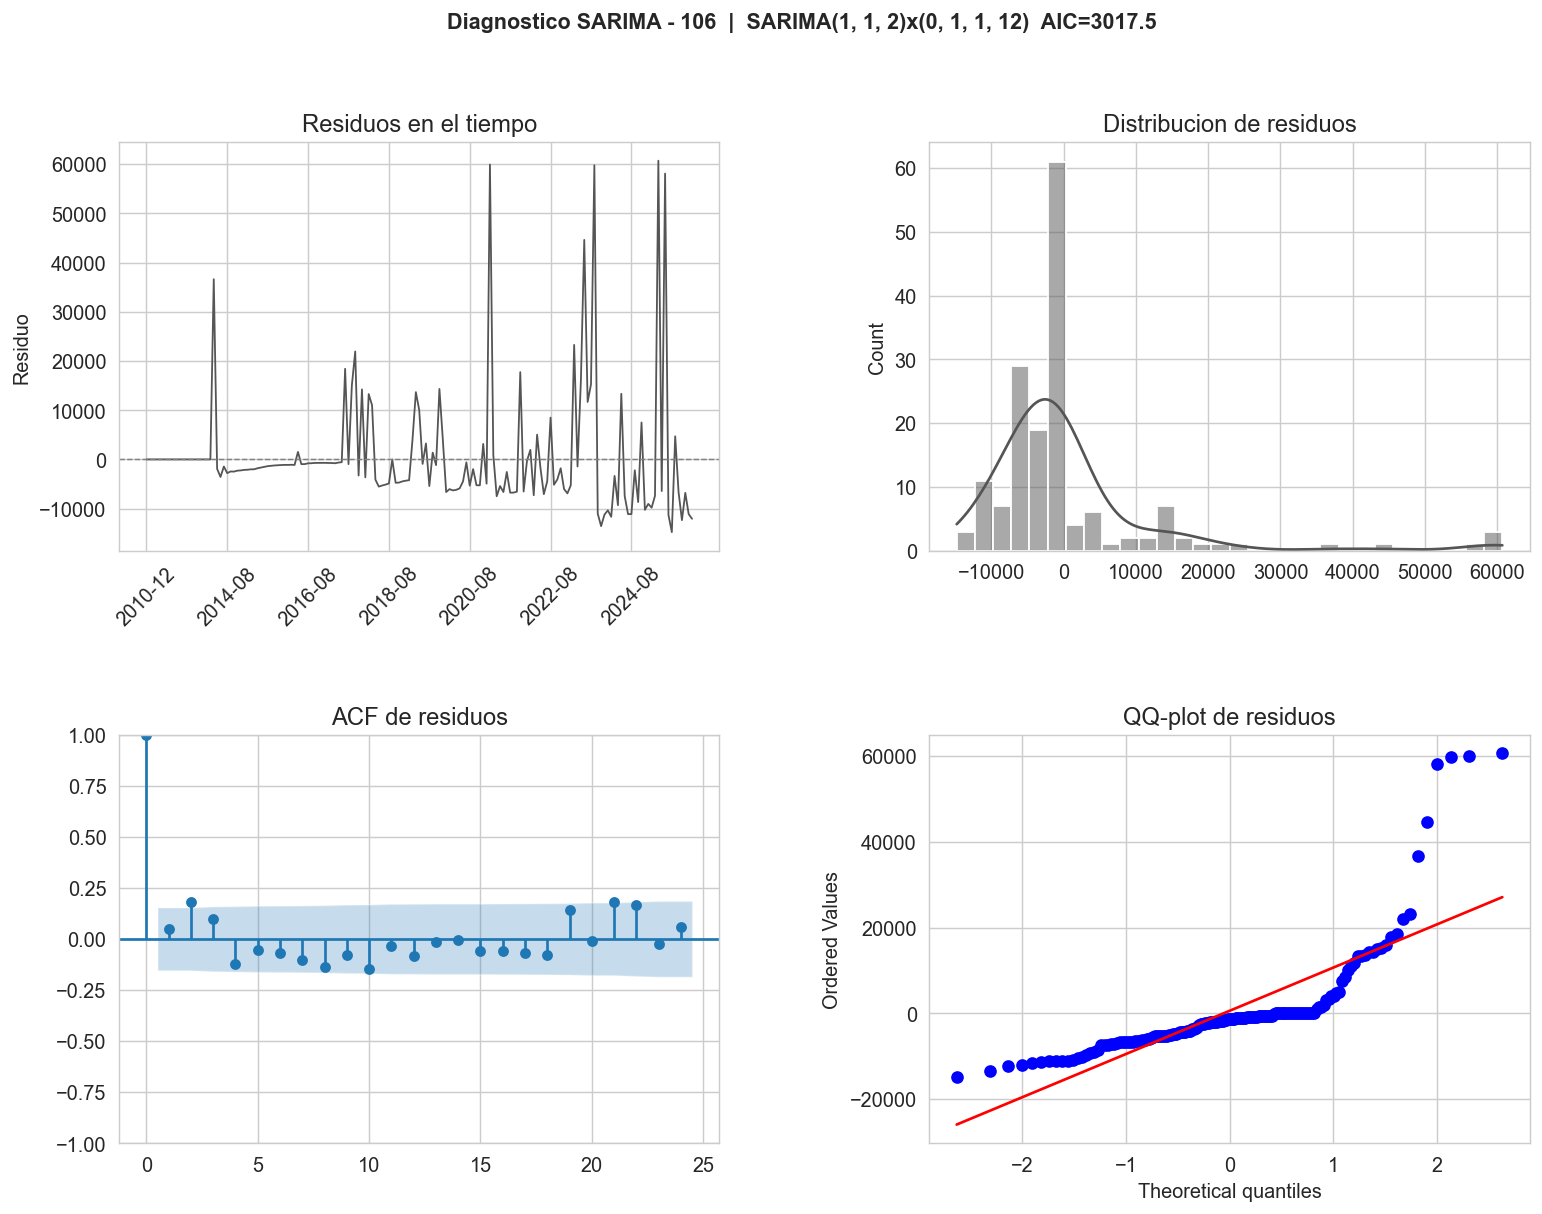

Figura guardada: ../figuras/03_diagnostico_SARIMA_106.pdf
Ljung-Box [106]:
      lb_stat  lb_pvalue
12  22.512381   0.032163
24  41.676483   0.014023
  -> Autocorrelacion remanente: considerar orden mayor



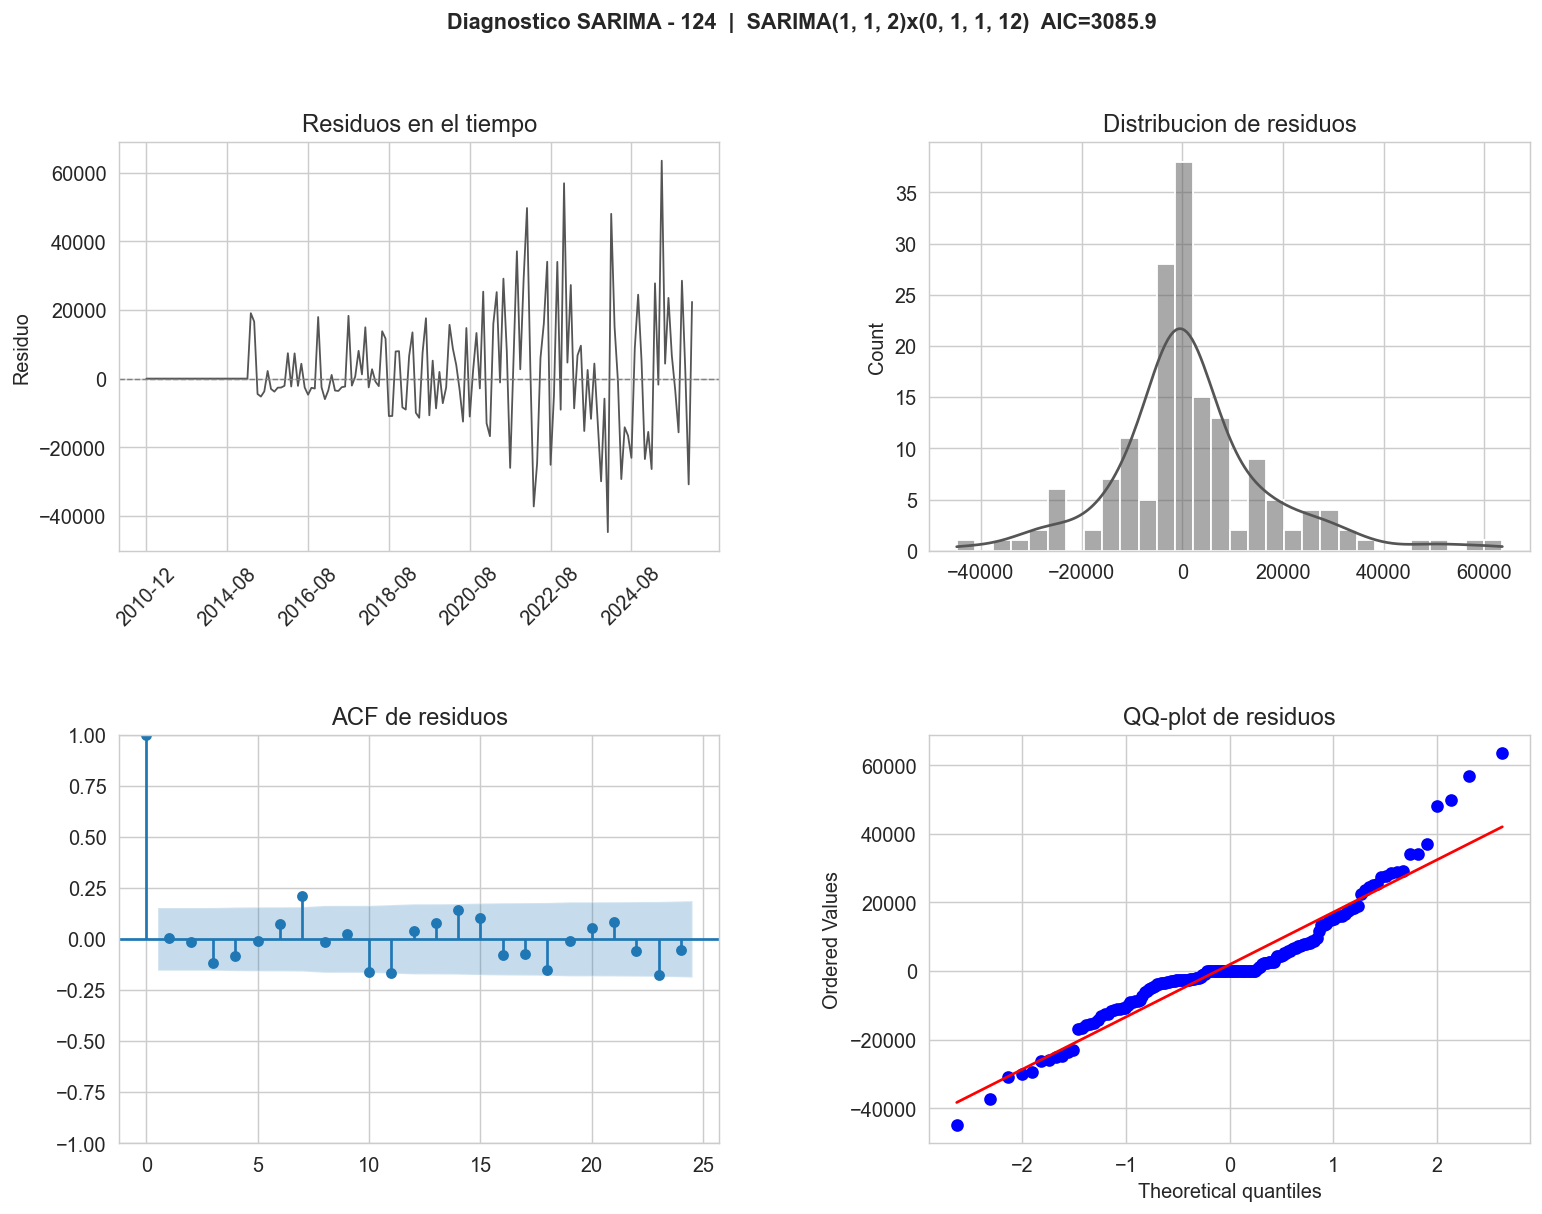

Figura guardada: ../figuras/03_diagnostico_SARIMA_124.pdf
Ljung-Box [124]:
      lb_stat  lb_pvalue
12  22.004426   0.037470
24  44.173854   0.007283
  -> Autocorrelacion remanente: considerar orden mayor



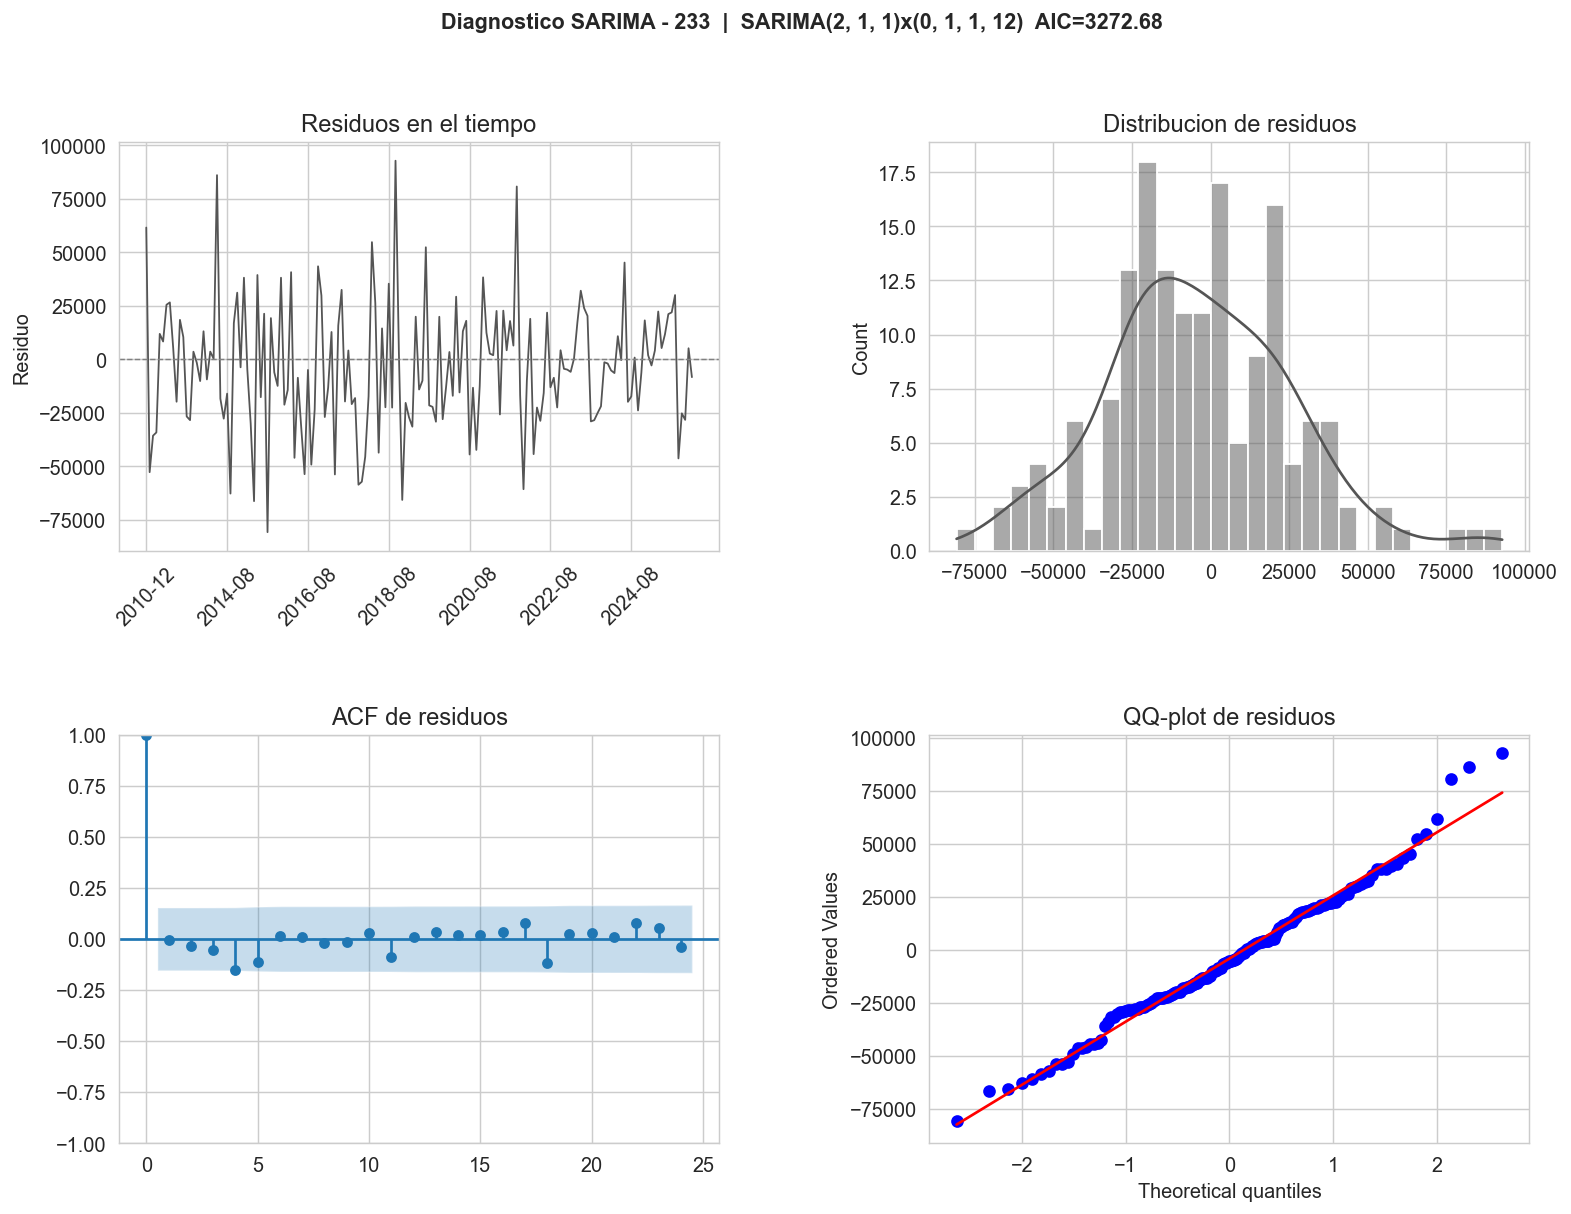

Figura guardada: ../figuras/03_diagnostico_SARIMA_233.pdf
Ljung-Box [233]:
      lb_stat  lb_pvalue
12   8.547098   0.741050
24  15.000080   0.920756
  -> Residuos no autocorrelacionados (ruido blanco)



In [6]:
modelos_sarima = {}

for familia in FAMILIAS:
    serie_full = ventas_mensual[familia].values
    ords       = ordenes_sarima[familia]

    model = SARIMAX(
        serie_full,
        order=ords['order'],
        seasonal_order=ords['seasonal_order'],
        enforce_stationarity=False,
        enforce_invertibility=False
    )
    res = model.fit(disp=False)
    modelos_sarima[familia] = res

    residuos = res.resid
    color    = COLORES.get(familia, '#555')
    idx_str  = ventas_mensual.index.astype(str)

    fig = plt.figure(figsize=(14, 10))
    gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.35)

    ax0 = fig.add_subplot(gs[0, 0])
    ax0.plot(idx_str, residuos, color=color, lw=1.0)
    ax0.axhline(0, color='grey', lw=0.8, ls='--')
    ticks = range(0, len(idx_str), 24)
    ax0.set_xticks([idx_str[i] for i in ticks])
    ax0.tick_params(axis='x', rotation=45)
    ax0.set_title('Residuos en el tiempo')
    ax0.set_ylabel('Residuo')

    ax1 = fig.add_subplot(gs[0, 1])
    sns.histplot(residuos, kde=True, ax=ax1, color=color, bins=30)
    ax1.set_title('Distribucion de residuos')

    ax2 = fig.add_subplot(gs[1, 0])
    plot_acf(residuos, lags=24, ax=ax2, alpha=ALPHA)
    ax2.set_title('ACF de residuos')

    ax3 = fig.add_subplot(gs[1, 1])
    stats.probplot(residuos, dist='norm', plot=ax3)
    ax3.set_title('QQ-plot de residuos')

    fig.suptitle(
        f'Diagnostico SARIMA - {familia}  |  '
        f'SARIMA{ords["order"]}x{ords["seasonal_order"]}  '
        f'AIC={ords["aic"]}',
        fontsize=12, fontweight='bold'
    )
    fname = f'../figuras/03_diagnostico_SARIMA_{familia}.pdf'
    plt.savefig(fname, bbox_inches='tight')
    plt.show()
    print(f'Figura guardada: {fname}')

    lb = acorr_ljungbox(residuos, lags=[12, 24], return_df=True)
    print(f'Ljung-Box [{familia}]:')
    print(lb.to_string())
    if (lb['lb_pvalue'] > ALPHA).all():
        print('  -> Residuos no autocorrelacionados (ruido blanco)')
    else:
        print('  -> Autocorrelacion remanente: considerar orden mayor')
    print()

### 2.3 Validacion walk-forward

Entrenamos con los primeros T-H meses y predecimos los ultimos H=12 meses.
Evita data leakage al no usar datos futuros en el entrenamiento.

In [7]:
resultados_sarima    = []
predicciones_sarima  = {}

for familia in FAMILIAS:
    serie_full = ventas_mensual[familia].values
    ords       = ordenes_sarima[familia]
    train_vals = serie_full[:-H]
    test_vals  = serie_full[-H:]

    model_wf = SARIMAX(
        train_vals,
        order=ords['order'],
        seasonal_order=ords['seasonal_order'],
        enforce_stationarity=False,
        enforce_invertibility=False
    )
    res_wf  = model_wf.fit(disp=False)
    fc_obj  = res_wf.get_forecast(steps=H)
    fc_mean = fc_obj.predicted_mean
    fc_ci   = fc_obj.conf_int(alpha=ALPHA)

    metricas = calcular_metricas(test_vals, fc_mean, 'SARIMA', familia)
    resultados_sarima.append(metricas)
    predicciones_sarima[familia] = {
        'test'     : test_vals,
        'fc_mean'  : fc_mean,
        'fc_lower' : fc_ci[:, 0],
        'fc_upper' : fc_ci[:, 1],
    }

    print(f'[{familia}]  RMSE={metricas["RMSE"]:>10.2f}  '
          f'MAPE={metricas["MAPE_%"]:>6.2f}%  '
          f'SMAPE={metricas["SMAPE_%"]:>6.2f}%')

print('\nWalk-forward SARIMA completado.')

[106]  RMSE=  26055.73  MAPE=669.27%  SMAPE=125.27%
[124]  RMSE=  32385.35  MAPE= 34.20%  SMAPE= 43.93%
[233]  RMSE=  23465.22  MAPE= 55.00%  SMAPE= 69.19%

Walk-forward SARIMA completado.


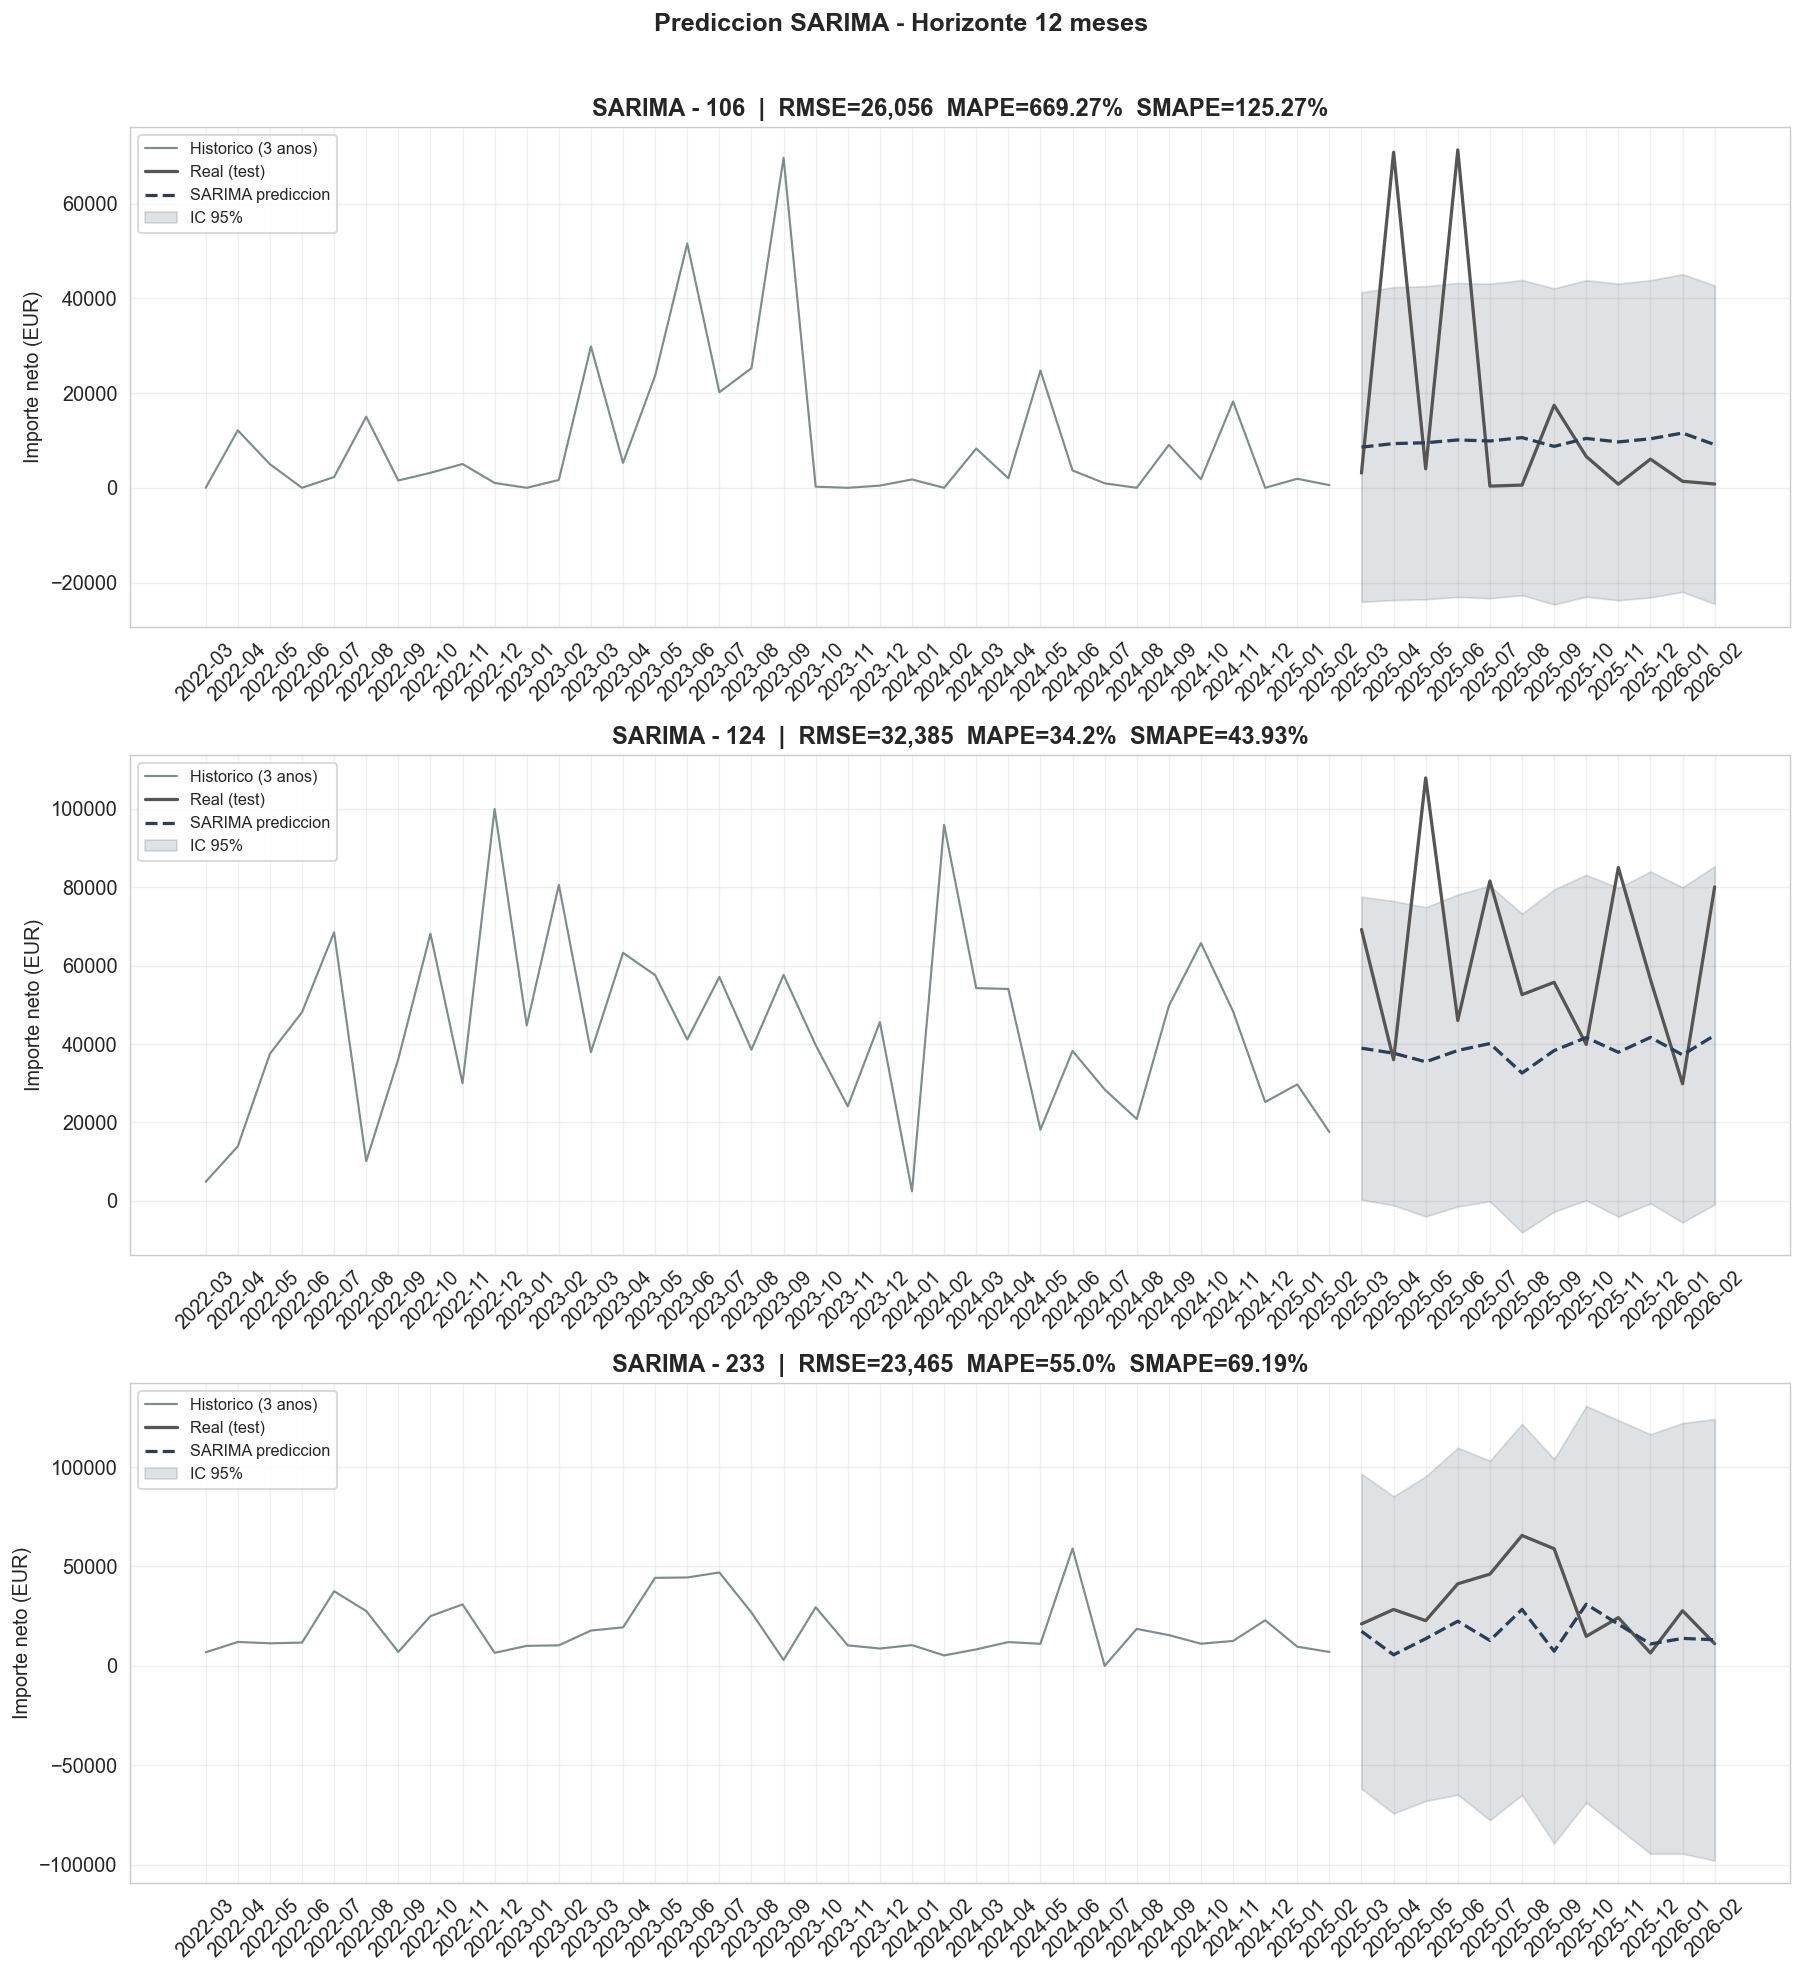

Figura guardada: figuras/03_prediccion_SARIMA.pdf


In [8]:
fig, axes = plt.subplots(len(FAMILIAS), 1,
                          figsize=(14, 5 * len(FAMILIAS)), sharex=False)
if len(FAMILIAS) == 1:
    axes = [axes]

for ax, familia in zip(axes, FAMILIAS):
    color    = COLORES.get(familia, '#555')
    serie    = ventas_mensual[familia].values
    n        = len(serie)
    pred     = predicciones_sarima[familia]
    test_idx = ventas_mensual.index[-H:].astype(str)

    ctx_start = n - H - 36
    ctx_idx   = ventas_mensual.index[ctx_start:].astype(str)
    ctx_train = serie[ctx_start:-H]

    ax.plot(list(ctx_idx[:36]), ctx_train,
            color='#7f8c8d', lw=1.2, label='Historico (3 anos)')
    ax.plot(list(test_idx), pred['test'],
            color=color, lw=1.8, label='Real (test)')
    ax.plot(list(test_idx), pred['fc_mean'],
            color='#2c3e50', lw=1.8, ls='--', label='SARIMA prediccion')
    ax.fill_between(list(test_idx),
                    pred['fc_lower'], pred['fc_upper'],
                    alpha=0.15, color='#2c3e50',
                    label=f'IC {int((1-ALPHA)*100)}%')

    m = next(r for r in resultados_sarima if r['Familia'] == familia)
    ax.set_title(
        f'SARIMA - {familia}  |  RMSE={m["RMSE"]:,.0f}  '
        f'MAPE={m["MAPE_%"]}%  SMAPE={m["SMAPE_%"]}%',
        fontweight='bold'
    )
    ax.set_ylabel('Importe neto (EUR)')
    ax.legend(loc='upper left', fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis='x', rotation=45)

plt.suptitle('Prediccion SARIMA - Horizonte 12 meses',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../figuras/03_prediccion_SARIMA.pdf', bbox_inches='tight')
plt.show()
print('Figura guardada: figuras/03_prediccion_SARIMA.pdf')

## 3. Modelo Prophet

Prophet descompone la serie como:
y(t) = g(t) + s(t) + h(t) + error

- g(t): tendencia lineal por tramos con changepoints automaticos
- s(t): estacionalidad via series de Fourier
- h(t): efectos de eventos especiales

Ventaja frente a SARIMA: maneja changepoints automaticamente
y es robusto a valores faltantes.

In [9]:
resultados_prophet   = []
predicciones_prophet = {}
modelos_prophet      = {}

for familia in FAMILIAS:
    serie = ventas_mensual[familia]

    df_p = pd.DataFrame({
        'ds': fechas_dt,
        'y' : serie.values
    })

    df_train = df_p.iloc[:-H]
    df_test  = df_p.iloc[-H:]

    m = Prophet(
        seasonality_mode        = 'additive',
        yearly_seasonality      = True,
        weekly_seasonality      = False,
        daily_seasonality       = False,
        changepoint_prior_scale = 0.05,
        seasonality_prior_scale = 10.0,
        interval_width          = 1 - ALPHA
    )
    m.add_seasonality(name='mensual', period=30.5, fourier_order=6)
    m.fit(df_train)
    modelos_prophet[familia] = m

    future   = m.make_future_dataframe(periods=H, freq='MS')
    forecast = m.predict(future)

    fc_mean  = forecast['yhat'].values[-H:]
    fc_lower = forecast['yhat_lower'].values[-H:]
    fc_upper = forecast['yhat_upper'].values[-H:]
    test_vals = df_test['y'].values

    metricas = calcular_metricas(test_vals, fc_mean, 'Prophet', familia)
    resultados_prophet.append(metricas)
    predicciones_prophet[familia] = {
        'test'         : test_vals,
        'fc_mean'      : fc_mean,
        'fc_lower'     : fc_lower,
        'fc_upper'     : fc_upper,
        'forecast_full': forecast,
    }

    print(f'[{familia}]  RMSE={metricas["RMSE"]:>10.2f}  '
          f'MAPE={metricas["MAPE_%"]:>6.2f}%  '
          f'SMAPE={metricas["SMAPE_%"]:>6.2f}%')

print('\nProphet completado.')

15:28:20 - cmdstanpy - INFO - Chain [1] start processing
15:28:20 - cmdstanpy - INFO - Chain [1] done processing
15:28:20 - cmdstanpy - INFO - Chain [1] start processing
15:28:20 - cmdstanpy - INFO - Chain [1] done processing


[106]  RMSE=  24671.74  MAPE=1206.45%  SMAPE=134.39%


15:28:21 - cmdstanpy - INFO - Chain [1] start processing
15:28:21 - cmdstanpy - INFO - Chain [1] done processing


[124]  RMSE=  35810.77  MAPE= 37.18%  SMAPE= 49.84%
[233]  RMSE=  30132.77  MAPE= 65.70%  SMAPE= 97.58%

Prophet completado.


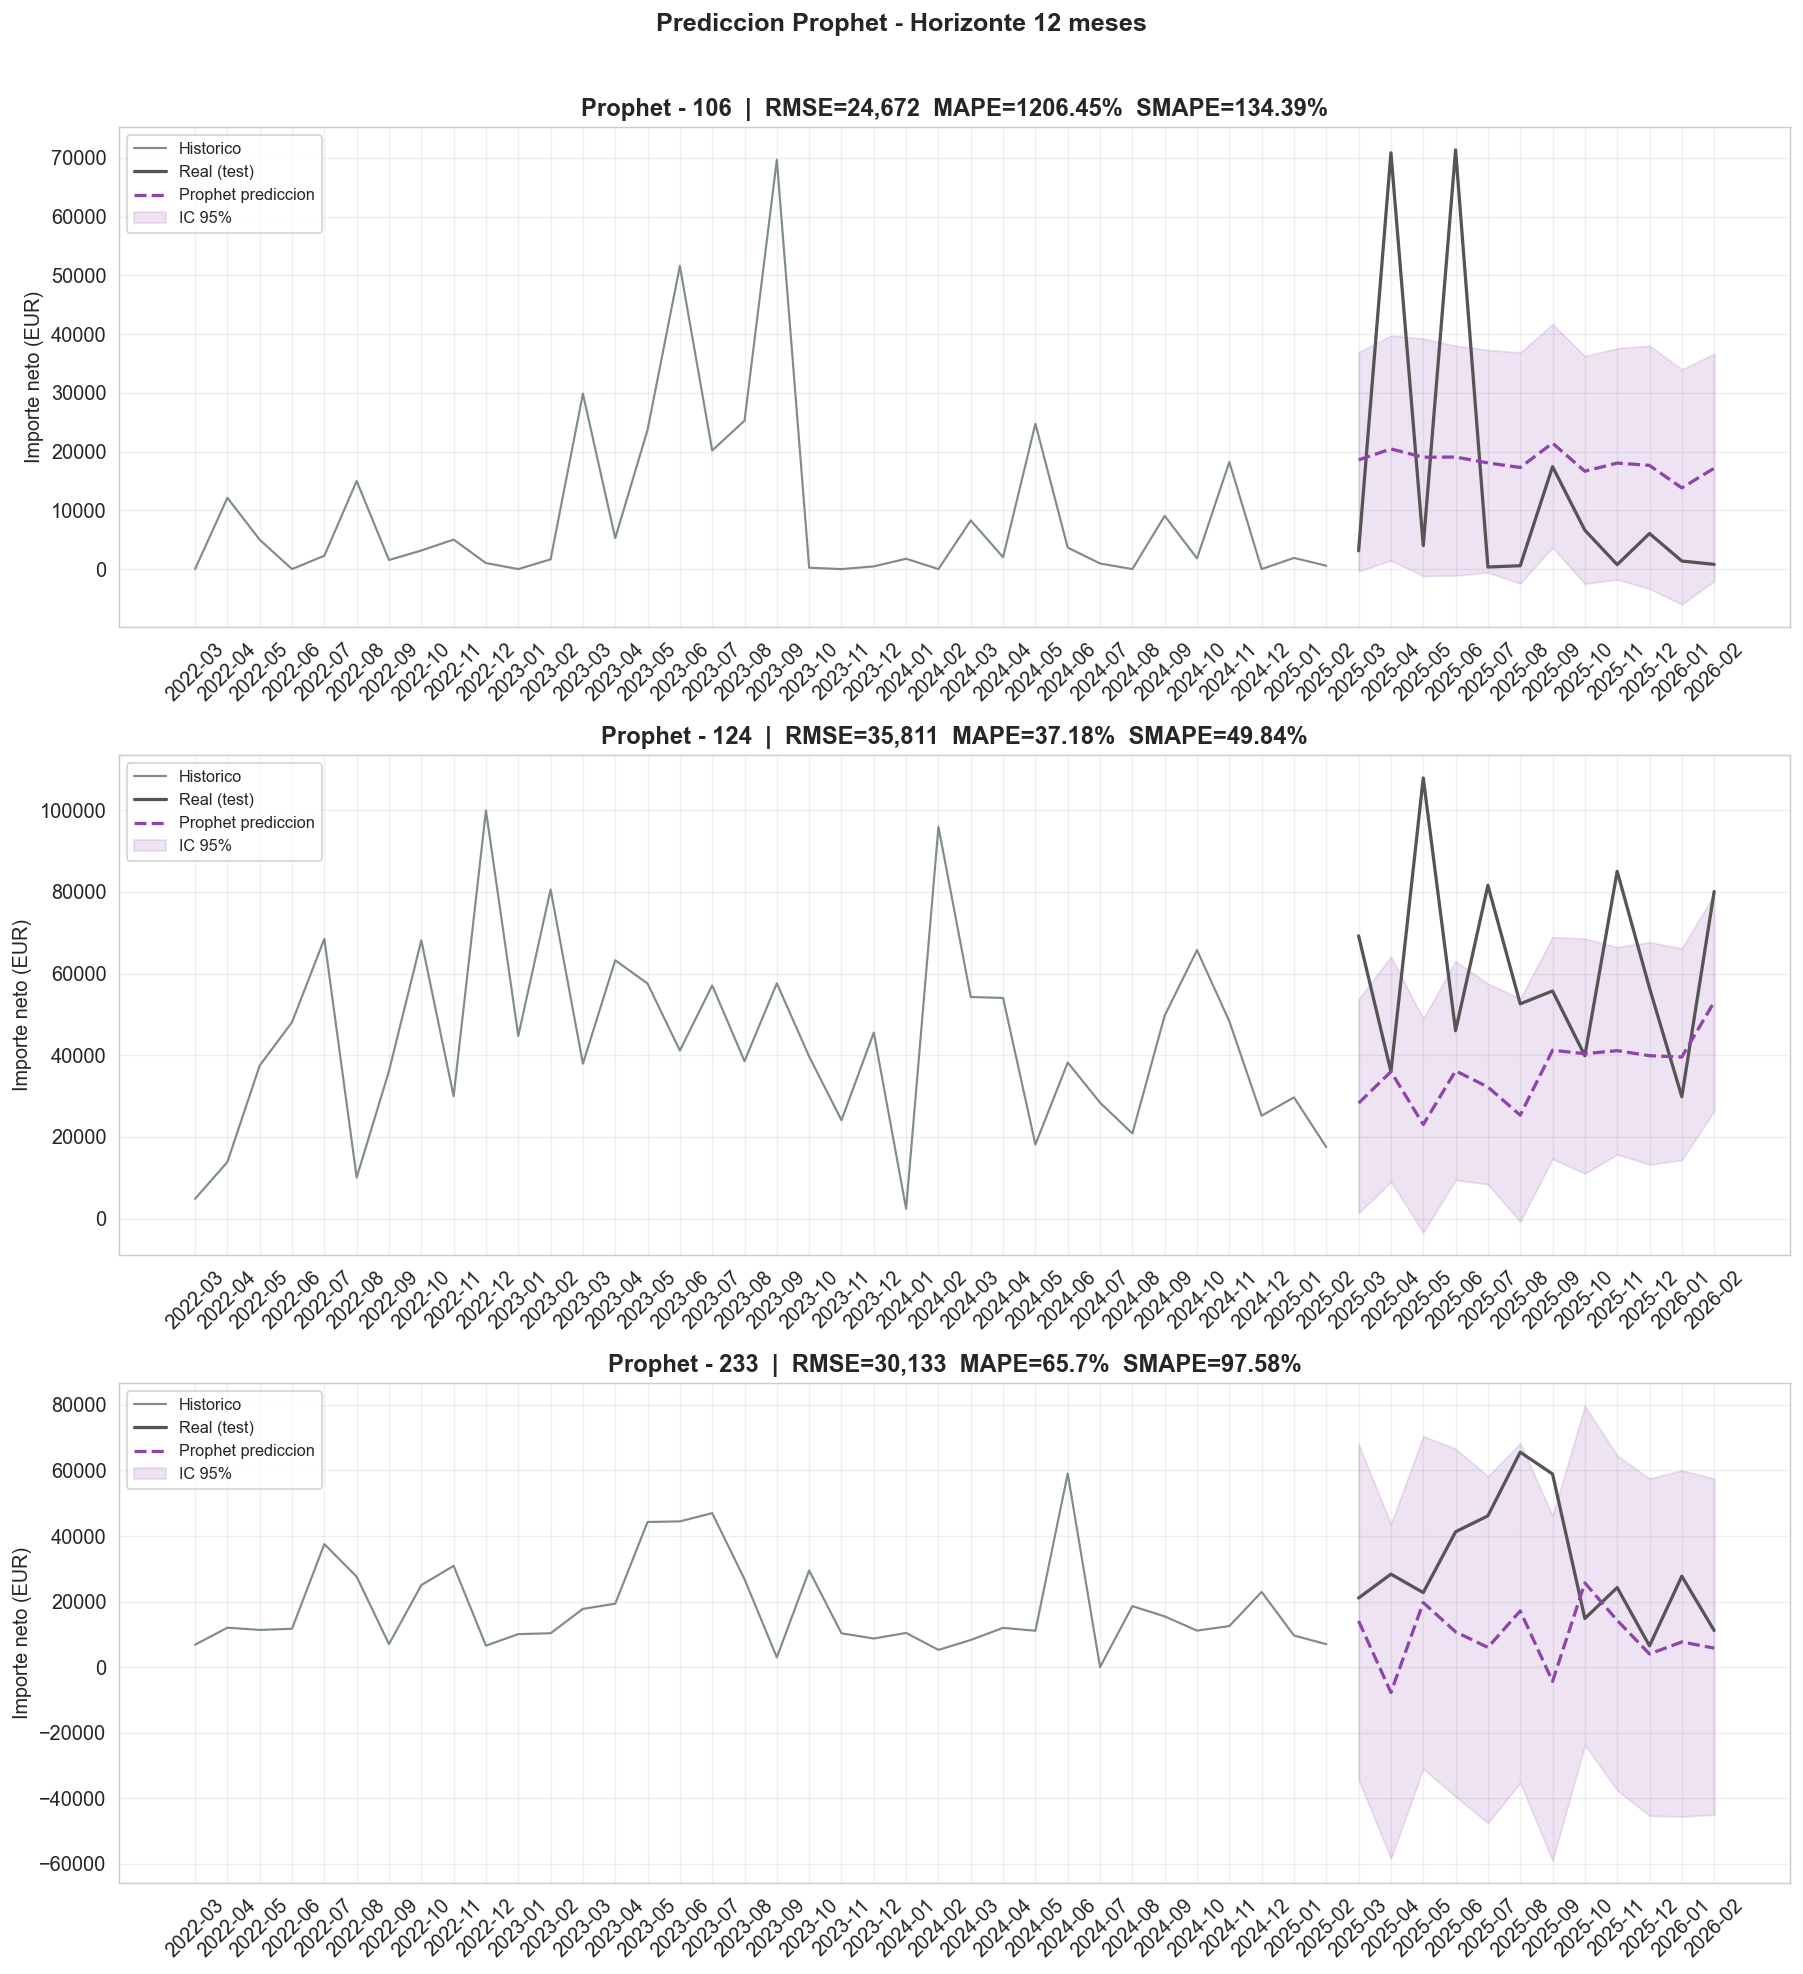

Figura guardada: figuras/03_prediccion_Prophet.pdf


In [10]:
fig, axes = plt.subplots(len(FAMILIAS), 1,
                          figsize=(14, 5 * len(FAMILIAS)), sharex=False)
if len(FAMILIAS) == 1:
    axes = [axes]

for ax, familia in zip(axes, FAMILIAS):
    color    = COLORES.get(familia, '#555')
    serie    = ventas_mensual[familia].values
    n        = len(serie)
    pred     = predicciones_prophet[familia]
    test_idx = ventas_mensual.index[-H:].astype(str)

    ctx_start = n - H - 36
    ctx_idx   = ventas_mensual.index[ctx_start:].astype(str)
    ctx_train = serie[ctx_start:-H]

    ax.plot(list(ctx_idx[:36]), ctx_train,
            color='#7f8c8d', lw=1.2, label='Historico')
    ax.plot(list(test_idx), pred['test'],
            color=color, lw=1.8, label='Real (test)')
    ax.plot(list(test_idx), pred['fc_mean'],
            color='#8e44ad', lw=1.8, ls='--', label='Prophet prediccion')
    ax.fill_between(list(test_idx),
                    pred['fc_lower'], pred['fc_upper'],
                    alpha=0.15, color='#8e44ad',
                    label=f'IC {int((1-ALPHA)*100)}%')

    m_res = next(r for r in resultados_prophet if r['Familia'] == familia)
    ax.set_title(
        f'Prophet - {familia}  |  RMSE={m_res["RMSE"]:,.0f}  '
        f'MAPE={m_res["MAPE_%"]}%  SMAPE={m_res["SMAPE_%"]}%',
        fontweight='bold'
    )
    ax.set_ylabel('Importe neto (EUR)')
    ax.legend(loc='upper left', fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis='x', rotation=45)

plt.suptitle('Prediccion Prophet - Horizonte 12 meses',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../figuras/03_prediccion_Prophet.pdf', bbox_inches='tight')
plt.show()
print('Figura guardada: figuras/03_prediccion_Prophet.pdf')

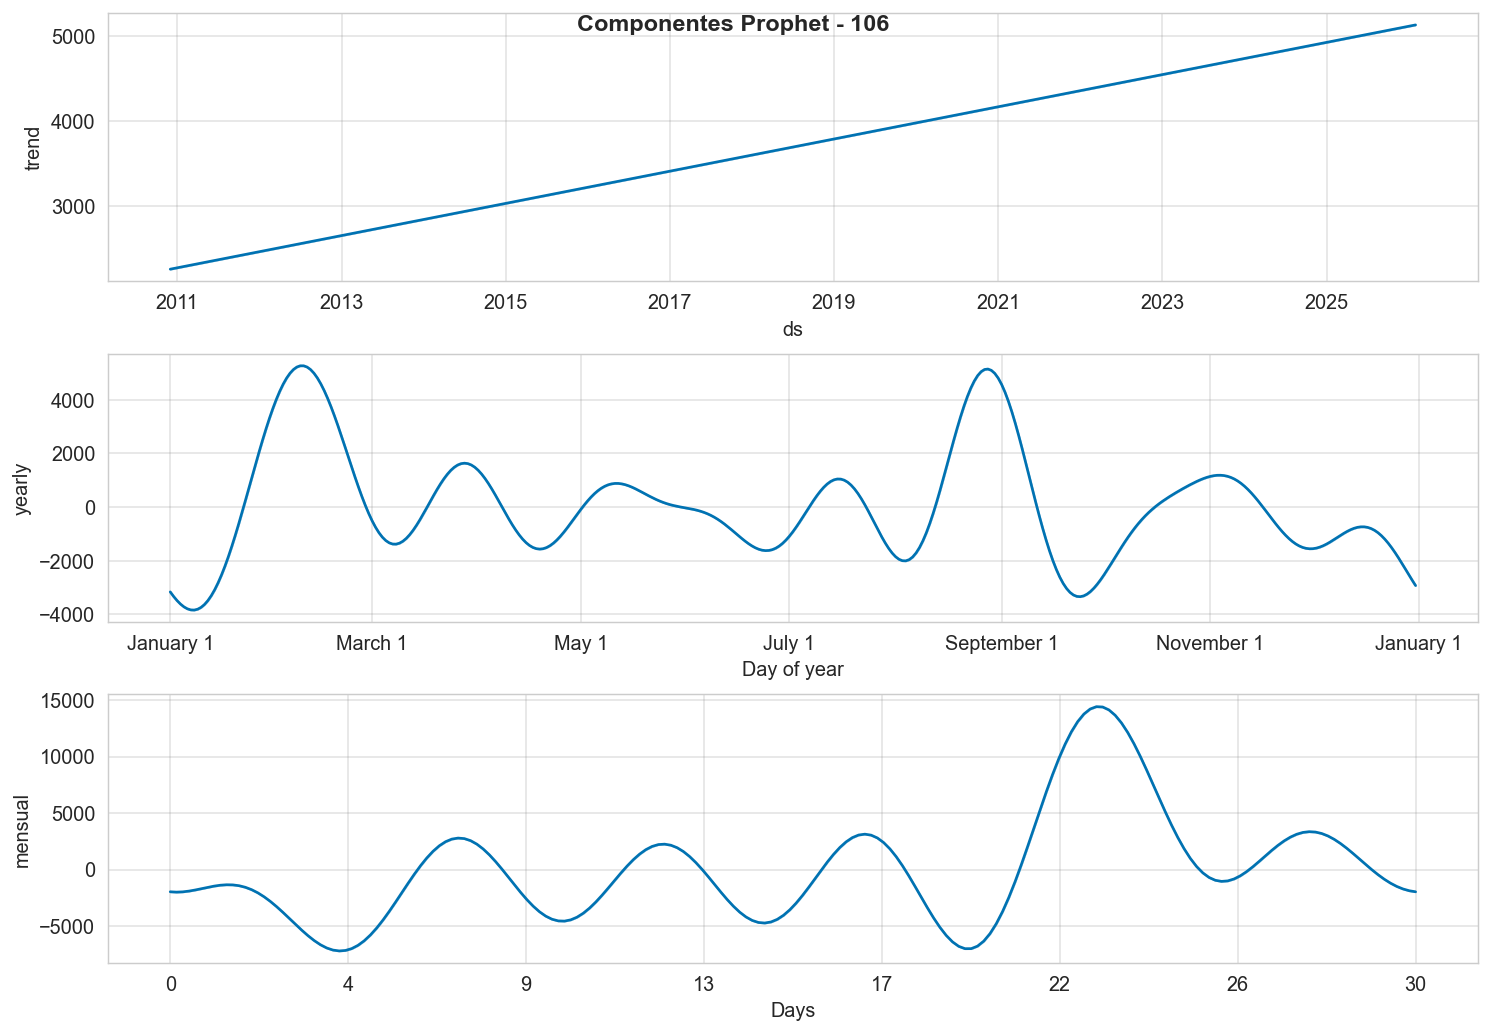

Figura guardada: ../figuras/03_componentes_Prophet_106.pdf


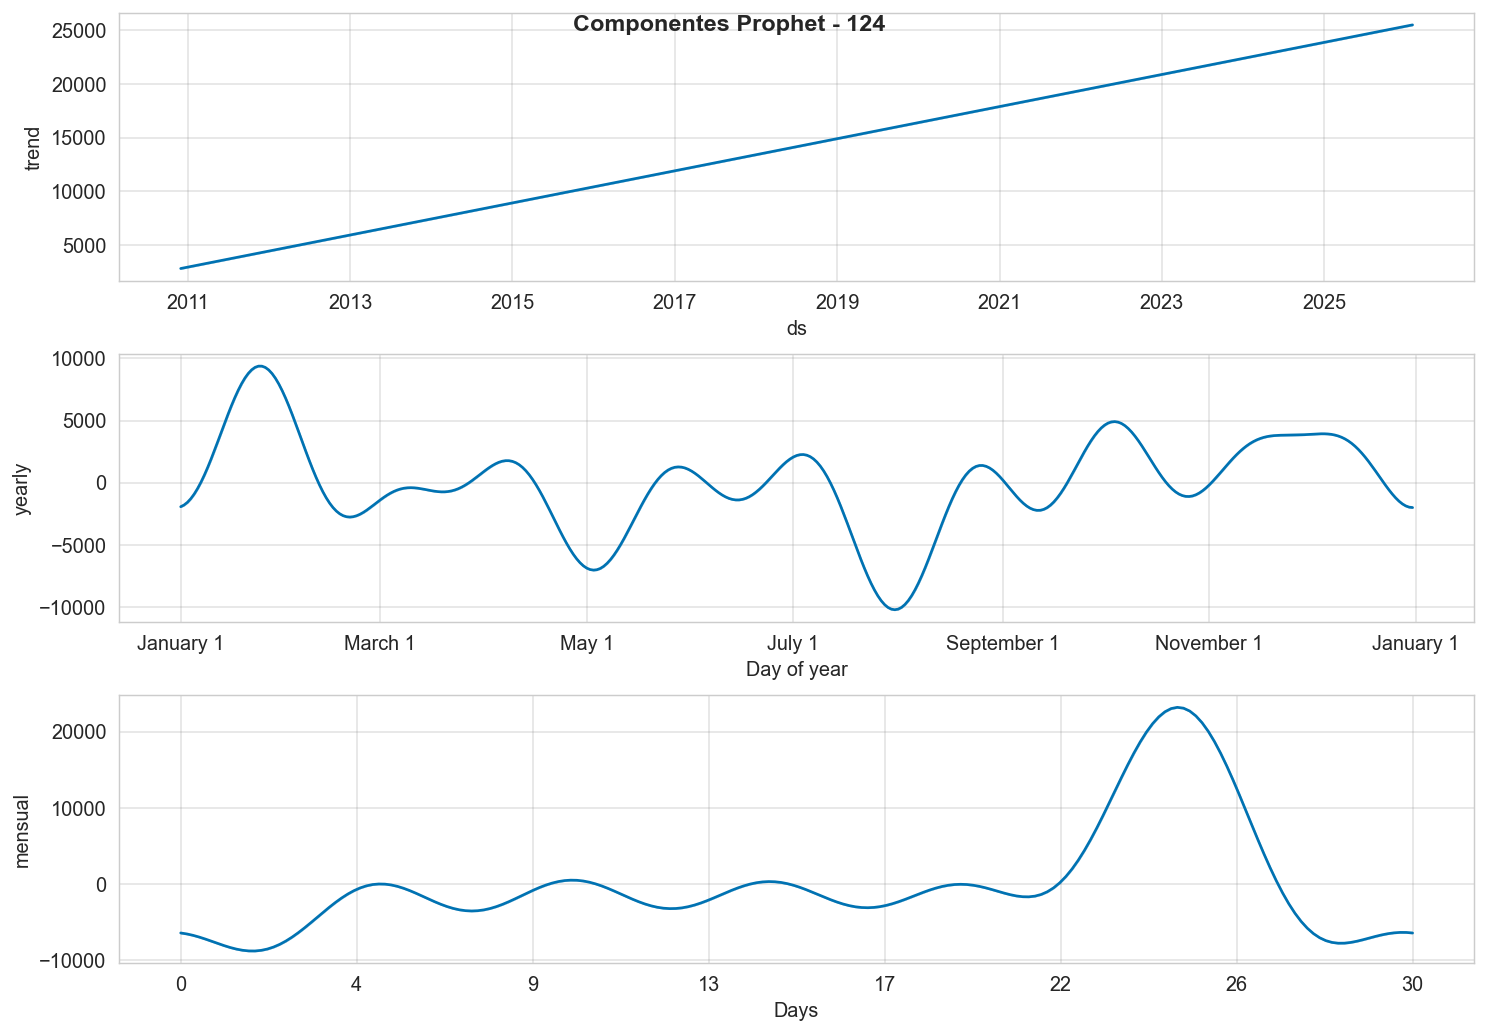

Figura guardada: ../figuras/03_componentes_Prophet_124.pdf


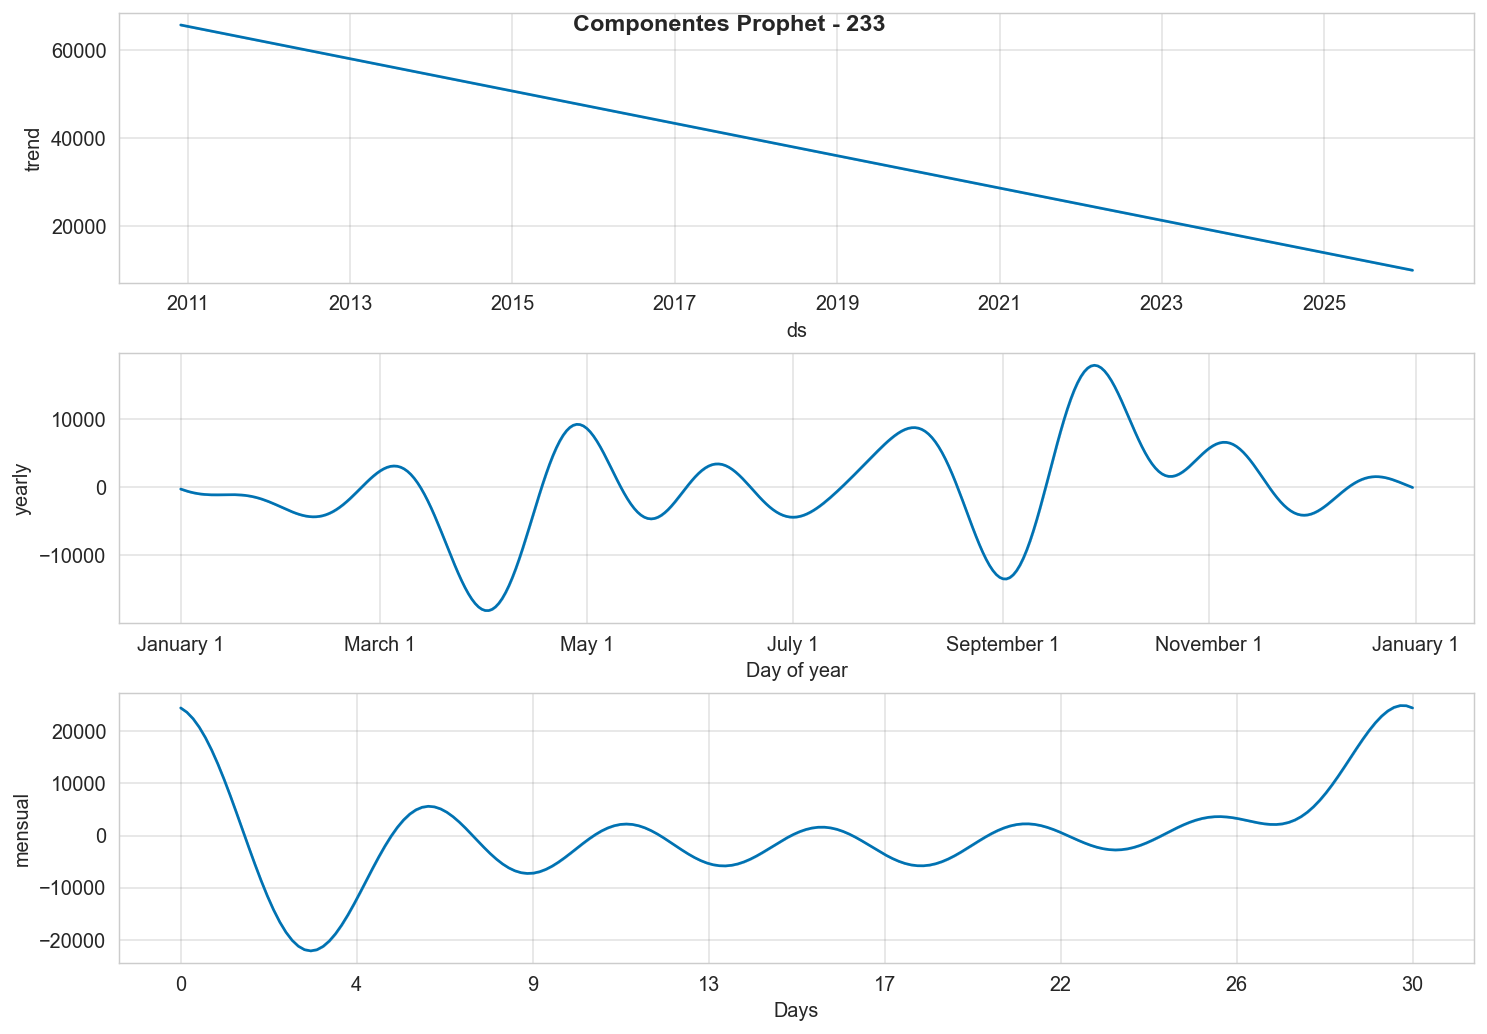

Figura guardada: ../figuras/03_componentes_Prophet_233.pdf


In [11]:
for familia in FAMILIAS:
    m        = modelos_prophet[familia]
    forecast = predicciones_prophet[familia]['forecast_full']
    fig      = m.plot_components(forecast)
    fig.set_size_inches(12, 8)
    fig.suptitle(f'Componentes Prophet - {familia}',
                 fontsize=13, fontweight='bold')
    fname = f'../figuras/03_componentes_Prophet_{familia}.pdf'
    fig.savefig(fname, bbox_inches='tight')
    plt.show()
    print(f'Figura guardada: {fname}')

## 4. Comparativa SARIMA vs Prophet

In [12]:
df_metricas = pd.DataFrame(resultados_sarima + resultados_prophet)
df_pivot    = df_metricas.pivot_table(
    index='Familia', columns='Modelo',
    values=['RMSE', 'MAE', 'MAPE_%', 'SMAPE_%']
).round(2)

print('Tabla comparativa:')
print(df_pivot.to_string())

df_metricas.to_csv('../data/processed/03_metricas_SARIMA_Prophet.csv', index=False)
print('\nCSV guardado: data/processed/03_metricas_SARIMA_Prophet.csv')

Tabla comparativa:
              MAE             MAPE_%              RMSE           SMAPE_%        
Modelo    Prophet    SARIMA  Prophet  SARIMA   Prophet    SARIMA Prophet  SARIMA
Familia                                                                         
106      19945.14  16457.26  1206.45  669.27  24671.74  26055.73  134.39  125.27
124      27039.83  24994.17    37.18   34.20  35810.77  32385.35   49.84   43.93
233      23091.93  18024.64    65.70   55.00  30132.77  23465.22   97.58   69.19

CSV guardado: data/processed/03_metricas_SARIMA_Prophet.csv


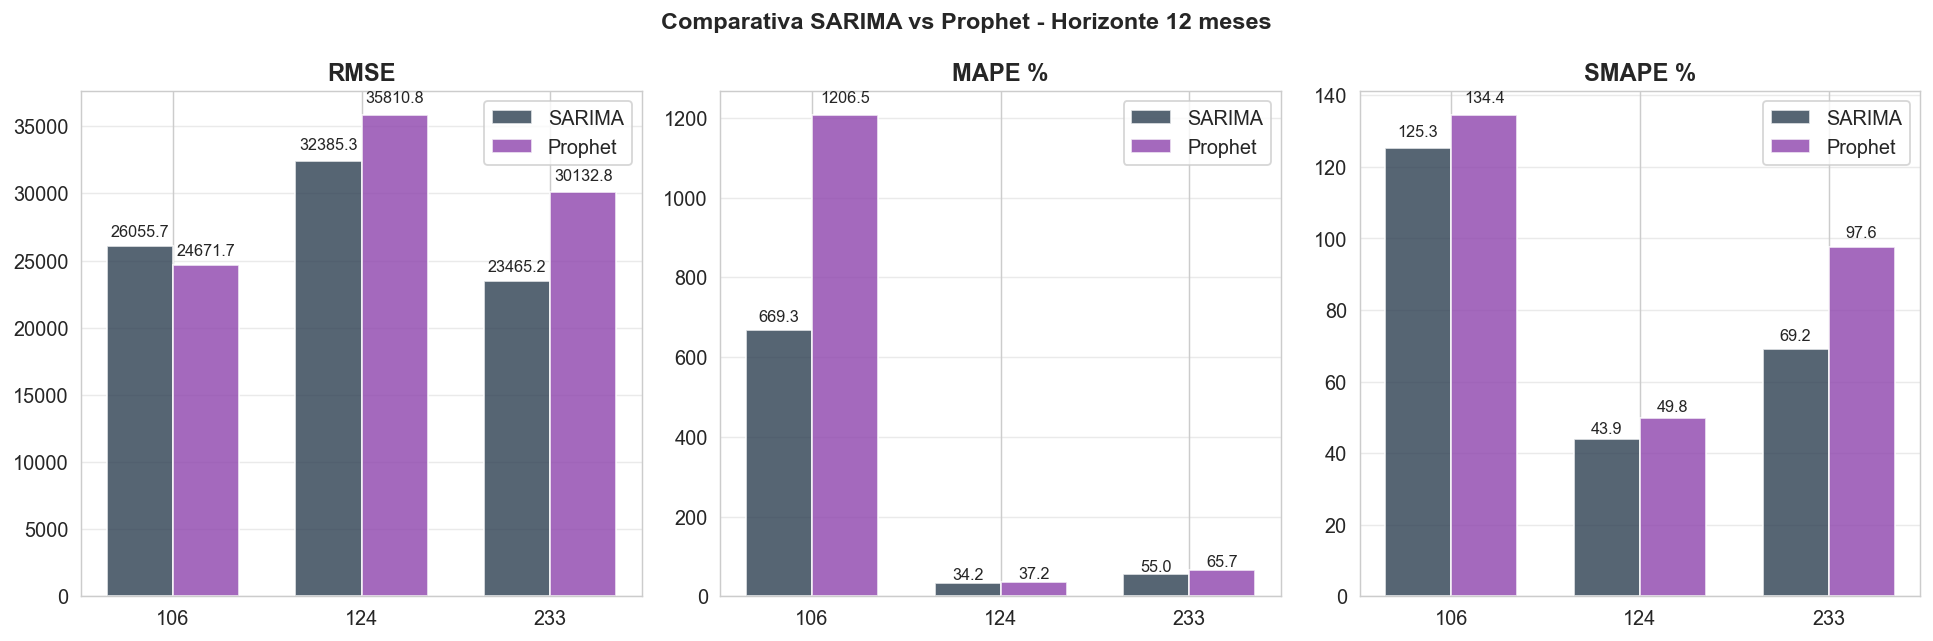

Figura guardada: figuras/03_comparativa_metricas.pdf


In [13]:
metrics_plot = ['RMSE', 'MAPE_%', 'SMAPE_%']
fig, axes    = plt.subplots(1, 3, figsize=(15, 5))
familias_ord = sorted(FAMILIAS)
x     = np.arange(len(familias_ord))
width = 0.35

for ax, metric in zip(axes, metrics_plot):
    sub    = df_metricas[df_metricas['Familia'].isin(familias_ord)]
    vals_s = [sub[(sub.Familia == f) & (sub.Modelo == 'SARIMA')][metric].values[0]
              for f in familias_ord]
    vals_p = [sub[(sub.Familia == f) & (sub.Modelo == 'Prophet')][metric].values[0]
              for f in familias_ord]

    bars1 = ax.bar(x - width/2, vals_s, width, label='SARIMA',
                   color='#2c3e50', alpha=0.8)
    bars2 = ax.bar(x + width/2, vals_p, width, label='Prophet',
                   color='#8e44ad', alpha=0.8)

    ax.set_xticks(x)
    ax.set_xticklabels(familias_ord)
    ax.set_title(metric.replace('_', ' '), fontweight='bold')
    ax.legend()
    ax.grid(axis='y', alpha=0.4)

    for bar in list(bars1) + list(bars2):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() * 1.02,
                f'{bar.get_height():.1f}',
                ha='center', va='bottom', fontsize=9)

plt.suptitle('Comparativa SARIMA vs Prophet - Horizonte 12 meses',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../figuras/03_comparativa_metricas.pdf', bbox_inches='tight')
plt.show()
print('Figura guardada: figuras/03_comparativa_metricas.pdf')

## 5. Exportacion de predicciones para optimizacion de stock

In [14]:
fechas_test = ventas_mensual.index[-H:].to_timestamp()
rows = []

for familia in FAMILIAS:
    s_pred = predicciones_sarima[familia]
    p_pred = predicciones_prophet[familia]

    for i, fecha in enumerate(fechas_test):
        rows.append({
            'FECHA'        : fecha,
            'FAMILIA'      : familia,
            'REAL'         : s_pred['test'][i],
            'SARIMA_PRED'  : s_pred['fc_mean'][i],
            'SARIMA_LOWER' : s_pred['fc_lower'][i],
            'SARIMA_UPPER' : s_pred['fc_upper'][i],
            'PROPHET_PRED' : p_pred['fc_mean'][i],
            'PROPHET_LOWER': p_pred['fc_lower'][i],
            'PROPHET_UPPER': p_pred['fc_upper'][i],
        })

df_pred = pd.DataFrame(rows)
df_pred.to_csv('../data/processed/03_predicciones_test.csv', index=False)
print('Predicciones exportadas: data/processed/03_predicciones_test.csv')
df_pred.head()

Predicciones exportadas: data/processed/03_predicciones_test.csv


,FECHA,FAMILIA,REAL,SARIMA_PRED,SARIMA_LOWER,SARIMA_UPPER,PROPHET_PRED,PROPHET_LOWER,PROPHET_UPPER
0,2025-03-01,106,3125.12988,8587.789060,-24081.346780,41256.924900,18584.662561,-364.128801,36938.260563
1,2025-04-01,106,70852.02800,9338.384157,-23702.084943,42378.853257,20450.210925,1462.679215,39750.990965
2,2025-05-01,106,4015.92000,9512.888779,-23537.340272,42563.117830,19038.200613,-1168.116634,39253.275957
3,2025-06-01,106,71347.07600,10106.064288,-23049.868043,43261.996618,19069.729889,-1099.136447,38021.878463
4,2025-07-01,106,356.07000,9885.238052,-23317.972330,43088.448434,18078.169769,-579.792088,37297.873692


In [15]:
print('=' * 65)
print('RESUMEN NOTEBOOK 03')
print('=' * 65)

for familia in FAMILIAS:
    ords = ordenes_sarima[familia]
    m_s  = next(r for r in resultados_sarima  if r['Familia'] == familia)
    m_p  = next(r for r in resultados_prophet if r['Familia'] == familia)

    print(f'\n[{familia}]')
    print(f'  SARIMA{ords["order"]} x {ords["seasonal_order"]}')
    print(f'    AIC={ords["aic"]}  BIC={ords["bic"]}')
    print(f'    RMSE={m_s["RMSE"]:>10,.2f}  MAPE={m_s["MAPE_%"]:>6.2f}%')
    print(f'  Prophet:')
    print(f'    RMSE={m_p["RMSE"]:>10,.2f}  MAPE={m_p["MAPE_%"]:>6.2f}%')
    mejor = 'SARIMA' if m_s['MAPE_%'] < m_p['MAPE_%'] else 'Prophet'
    print(f'  -> Mejor modelo (MAPE): {mejor}')

print('\n' + '=' * 65)
print('Proximo: Notebook 04 - XGBoost con feature engineering temporal')

RESUMEN NOTEBOOK 03

[106]
  SARIMA(1, 1, 2) x (0, 1, 1, 12)
    AIC=3017.5  BIC=3032.14
    RMSE= 26,055.73  MAPE=669.27%
  Prophet:
    RMSE= 24,671.74  MAPE=1206.45%
  -> Mejor modelo (MAPE): SARIMA

[124]
  SARIMA(1, 1, 2) x (0, 1, 1, 12)
    AIC=3085.9  BIC=3100.54
    RMSE= 32,385.35  MAPE= 34.20%
  Prophet:
    RMSE= 35,810.77  MAPE= 37.18%
  -> Mejor modelo (MAPE): SARIMA

[233]
  SARIMA(2, 1, 1) x (0, 1, 1, 12)
    AIC=3272.68  BIC=3287.32
    RMSE= 23,465.22  MAPE= 55.00%
  Prophet:
    RMSE= 30,132.77  MAPE= 65.70%
  -> Mejor modelo (MAPE): SARIMA

Proximo: Notebook 04 - XGBoost con feature engineering temporal
